<a href="https://www.kaggle.com/code/stevemeadows/dfa-performance-comparison?scriptVersionId=235968987" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
!pip install statsforecast > /dev/null 2>&1

# Introduction

During my data science internship, I worked on a time series prediction problem to support our business partners by developing a statistical model to forecast order volume. The model incorporated internal variables, such as order pipeline and price changes, and external variables, including GDP and business-specific economic indicators. Drawing inspiration from my graduate-level coursework, I initially explored applying principal components analysis (PCA) and principal axis factoring (PAF) to this time series challenge.

However, this approach presented challenges. PCA and PAF assume data is static and non-temporal, making them unsuitable for time series data. After researching alternative methods, I discovered state-space models, specifically dynamic factor analysis (DFA). DFA is designed for temporal data and models the underlying latent factors that drive observed time series variables. It assumes that the observed data is generated by a combination of latent dynamic factors and noise, where the factors evolve over time according to a stochastic process, often modeled as a linear dynamical system. This allows DFA to capture temporal dependencies and reduce dimensionality in multivariate time series data, making it well-suited for forecasting order volume based on the interplay of internal and external variables.

After exploring options to implement this technique, I selected the MARSS package in R (https://cran.r-project.org/web/packages/MARSS/MARSS.pdf). The MARSS package, designed for fitting linear multivariate autoregressive state-space models, provides robust tools for dynamic factor analysis, enabling efficient estimation of latent factors and their temporal dynamics using methods like Expectation-Maximization and BFGS optimization. Its flexibility in handling missing data and model constraints made it ideal for this application. After careful factor selection based on AICc criteria, I chose a reduction to six factors, which explained 55% of the variability in the internal and external variables using a promax rotation. This yielded six intuitive trends, informed by the variables with higher factor loadings. Below, I will demonstrate how this reduction impacted prediction model accuracy when using the latent trends as opposed to the raw data.

## Loading Dataset

For business confidentiality reasons, I could not use or display internal financial data. Instead, I selected a publicly available dataset from Kaggle, "Bike Sales Data of 100k" (https://www.kaggle.com/datasets/jayavarman/bike-sales-data-of-100k), which closely aligns with the characteristics of my internship project data. This dataset was chosen due to its matching time interval and its focus on durable goods, similar to the products analyzed in my project. 

The "Bike Sales Data of 100k" dataset, published on August 31, 2024, contains 100,000 records of bike sales, designed for retail analysis. It includes variables such as sales quantities, dates, product details, and potentially influencing factors like pricing or regional economic indicators, making it suitable for time series forecasting tasks. This dataset provides a robust proxy for studying order volume dynamics, allowing me to apply dynamic factor analysis (DFA) using the MARSS package to model latent trends and evaluate prediction accuracy.[](https://www.kaggle.com/datasets/jayavarman/bike-sales-data-of-100k)

In [2]:
# Load the DataFrames from CSV files
df_sales = pd.read_csv('/kaggle/input/bike-sales-data-of-100k/bike_sales_100k.csv')
df_promax = pd.read_csv('/kaggle/input/dfa-promax-trends-csv/dfa_promax_trends.csv')

# Convert date columns to datetime
df_sales['Date'] = pd.to_datetime(df_sales['Date'], dayfirst=True)  # dayfirst=True since dates are DD-MM-YYYY
df_promax['date'] = pd.to_datetime(df_promax['date'], format='%m/%d/%y')

# Calculate total sales (Price * Quantity) for each row
df_sales['Total_Sales'] = df_sales['Price'] * df_sales['Quantity']

# Aggregate sales by month
# Extract year and month to group by
df_sales['YearMonth'] = df_sales['Date'].dt.to_period('M')
monthly_sales = df_sales.groupby('YearMonth')['Total_Sales'].sum().reset_index()

# Convert YearMonth back to datetime for joining (first day of each month)
monthly_sales['Date'] = monthly_sales['YearMonth'].dt.to_timestamp()

# Filter monthly sales to only include dates present in df_promax
monthly_sales_filtered = monthly_sales[monthly_sales['Date'].isin(df_promax['date'])]

# Join the DataFrames
# Using merge on the date columns
result_df = pd.merge(df_promax, 
                    monthly_sales_filtered[['Date', 'Total_Sales']], 
                    left_on='date', 
                    right_on='Date', 
                    how='left')

# Drop the extra Date column from the join if you don't need it
result_df = result_df.drop(columns=['Date'])

# Optionally, rename Total_Sales to something more specific
result_df = result_df.rename(columns={'Total_Sales': 'Monthly_Bike_Sales'})

# Display the first few rows to verify
print(result_df.head())

        date        V1        V2        V3        V4        V5        V6  \
0 2022-06-01 -3.176707  0.018601 -5.172727 -3.464416  1.051282  0.715103   
1 2022-07-01 -3.248652 -1.374862 -5.140647 -2.775988  2.122289  1.548491   
2 2022-08-01 -3.388221 -0.720855 -4.652685 -2.671924  2.200777 -1.029698   
3 2022-09-01 -3.524006 -0.946106 -4.496715 -2.305112  0.857244 -3.065972   
4 2022-10-01 -2.035664  1.433024 -3.189621 -2.395486  1.286006 -2.205761   

   Monthly_Bike_Sales  
0         13706309.36  
1         14020423.25  
2         13686964.73  
3         13663398.39  
4         14085581.15  


In [3]:
# Rename 'date' to 'ds' and 'Monthly_Bike_Sales' to 'y'
result_df = result_df.rename(columns={'date': 'ds', 'Monthly_Bike_Sales': 'y'})

# Add a unique_id column (arbitrarily set to 'bike_sales' for all rows)
result_df['unique_id'] = 'bike_sales'

# Reorder columns to unique_id, ds, y, then all X variables (V1-V6)
x_vars = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
desired_columns = ['unique_id', 'ds', 'y'] + x_vars
result_df = result_df[desired_columns]

# Split into X and y DataFrames (keeping them as DataFrames)
# X will include unique_id, ds, and all predictor variables
X = result_df[['unique_id', 'ds'] + x_vars]
# y will include unique_id, ds, and the target variable
y = result_df[['unique_id', 'ds', 'y']]

# Perform the test-train split (last 6 months as test data)
total_months = len(result_df)
test_size = 6  # Last 6 months
train_size = total_months - test_size

# Split X into train and test DataFrames
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

# Split y into train and test DataFrames
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# Verify the split
print(f"Total months: {total_months}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check the first few rows of each
print("\nX_train sample:")
print(X_train.head())
print("\nX_test sample:")
print(X_test.head())
print("\ny_train sample:")
print(y_train.head())
print("\ny_test sample:")
print(y_test.head())

# Verify date ranges
print("\nTraining dates range:", X_train['ds'].min(), "to", X_train['ds'].max())
print("Test dates range:", X_test['ds'].min(), "to", X_test['ds'].max())

Total months: 27
X_train shape: (21, 8)
X_test shape: (6, 8)
y_train shape: (21, 3)
y_test shape: (6, 3)

X_train sample:
    unique_id         ds        V1        V2        V3        V4        V5  \
0  bike_sales 2022-06-01 -3.176707  0.018601 -5.172727 -3.464416  1.051282   
1  bike_sales 2022-07-01 -3.248652 -1.374862 -5.140647 -2.775988  2.122289   
2  bike_sales 2022-08-01 -3.388221 -0.720855 -4.652685 -2.671924  2.200777   
3  bike_sales 2022-09-01 -3.524006 -0.946106 -4.496715 -2.305112  0.857244   
4  bike_sales 2022-10-01 -2.035664  1.433024 -3.189621 -2.395486  1.286006   

         V6  
0  0.715103  
1  1.548491  
2 -1.029698  
3 -3.065972  
4 -2.205761  

X_test sample:
     unique_id         ds        V1        V2        V3        V4        V5  \
21  bike_sales 2024-03-01  2.288904 -2.829670  3.569741  1.320302 -0.085554   
22  bike_sales 2024-04-01  2.838695 -2.833305  3.831360  1.616793 -1.522805   
23  bike_sales 2024-05-01  3.874182 -2.728172  3.703377  1.540098 -0.840

In [4]:
y = pd.concat([y_train, y_test])

## Model Prediction Using DFA Trends

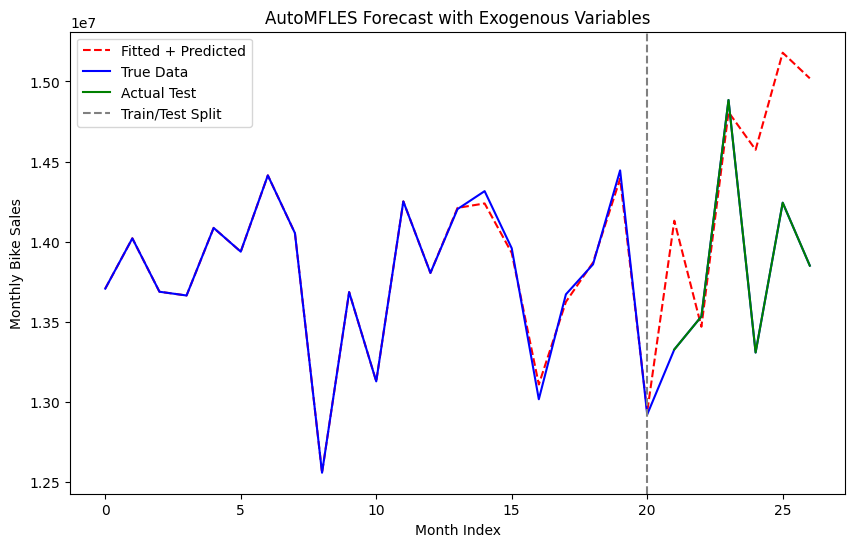


Forecast Results for the Last 6 Months:
     unique_id         ds     y_actual        y_pred
21  bike_sales 2024-03-01  13326290.26  1.413051e+07
22  bike_sales 2024-04-01  13532725.53  1.346817e+07
23  bike_sales 2024-05-01  14884378.63  1.480870e+07
24  bike_sales 2024-06-01  13307413.12  1.457358e+07
25  bike_sales 2024-07-01  14242926.94  1.517966e+07
26  bike_sales 2024-08-01  13849983.44  1.501971e+07

Mean Absolute Error (MAE): 719515.28
Root Mean Squared Error (RMSE): 866562.19


In [5]:
import matplotlib.pyplot as plt
from statsforecast.models import AutoMFLES

# Extract y_test values as a NumPy array
y_test_values = y_test['y'].values

# Combine full y data (train + test) for plotting true data
full_y = pd.concat([y_train[['ds', 'y']], y_test[['ds', 'y']]])
y_full_values = full_y['y'].values

# Initialize the AutoMFLES model
mfles_model = AutoMFLES(
    season_length=[12],  # Monthly seasonality
    test_size=6,         # Last 6 months for validation during fitting
    n_windows=3,         # Number of cross-validation windows
    metric='mae'         # Use MAE as the optimization metric
)

# Fit the model with training data
# y_train['y'] as NumPy array, X_train drops 'ds' and 'unique_id'
mfles_model.fit(
    y=y_train['y'].values,  # Extract 'y' column as NumPy array
    X=X_train.drop(['ds', 'unique_id'], axis=1).values  # Exogenous variables as NumPy array
)

# Forecast the next 6 periods using the test exogenous variables
predicted = mfles_model.predict(
    h=6,  # Horizon of 6 months
    X=X_test.drop(['ds', 'unique_id'], axis=1).values  # Future exogenous variables (no 'y' in X_test)
)['mean']

# Get in-sample fitted values
fitted = mfles_model.predict_in_sample()['fitted']

# Combine fitted and predicted values for plotting
f_n2 = np.concatenate([fitted, predicted])

# Prepare the leave-out (actual test data) for plotting
leave_out = pd.DataFrame({
    'x': np.arange(len(f_n2) - 6, len(f_n2), 1),  # Indices for the last 6 months
    'y': y_test_values  # Actual values for the last 6 months
})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(f_n2, linestyle='dashed', color='red', label='Fitted + Predicted')
plt.plot(y_full_values, label='True Data', color='blue')  # Plot full true data
plt.plot(leave_out['x'], leave_out['y'], color='green', linestyle='-', label='Actual Test')
plt.axvline(x=len(fitted) - 1, color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title('AutoMFLES Forecast with Exogenous Variables')
plt.xlabel('Month Index')
plt.ylabel('Monthly Bike Sales')
plt.show()

# Create a results DataFrame for comparison
results = pd.DataFrame({
    'unique_id': y_test['unique_id'],
    'ds': y_test['ds'],
    'y_actual': y_test_values,
    'y_pred': predicted
})
print("\nForecast Results for the Last 6 Months:")
print(results)

# Calculate error metrics
results['error'] = results['y_actual'] - results['y_pred']
mae = results['error'].abs().mean()
rmse = ((results['error'] ** 2).mean()) ** 0.5
print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

The MFLES model using the 6 trends produced an error of:

Mean Absolute Error (MAE): 719515.28
Root Mean Squared Error (RMSE): 866562.19

This error is accumulated over the the last 6 months of the data. Below I perform the same method using the actual 41 variables.


## Model Prediction Using All Exogenous Variables

In [6]:
# Load data
x_train = pd.read_csv("/kaggle/input/exogenous-variables/x_net_training.csv")
x_test = pd.read_csv("/kaggle/input/exogenous-variables/x_net_test.csv")


# Convert 'ds' column to datetime
x_train["ds"] = pd.to_datetime(x_train["ds"])
x_test["ds"] = pd.to_datetime(x_test["ds"])

# Add the same unique_id to both DataFrames
unique_id = 'bike_sales'  # You can change this to any identifier you prefer
x_train['unique_id'] = unique_id
x_test['unique_id'] = unique_id

# Optionally, reorder columns to have 'unique_id' first (if desired)
desired_columns = ['unique_id', 'ds'] + [col for col in x_train.columns if col not in ['unique_id', 'ds']]
x_train = x_train[desired_columns]
x_test = x_test[desired_columns]

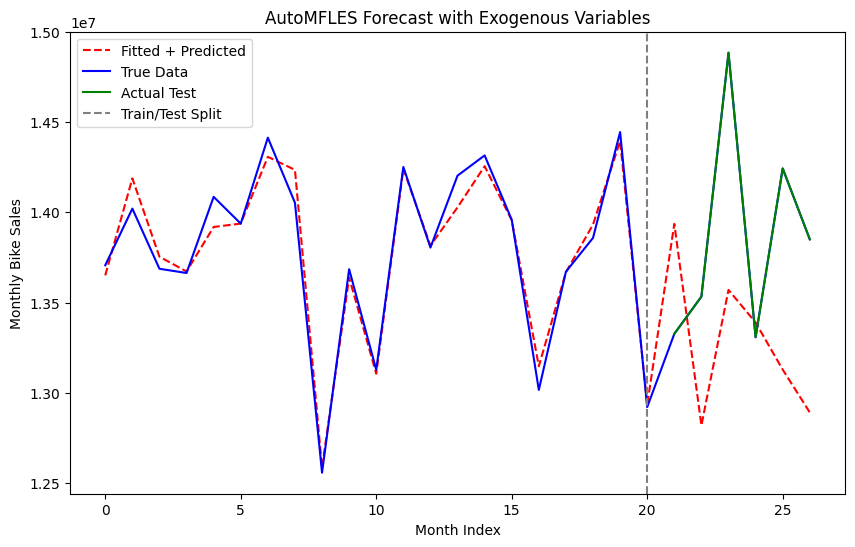


Forecast Results for the Last 6 Months:
     unique_id         ds     y_actual        y_pred
21  bike_sales 2024-03-01  13326290.26  1.393580e+07
22  bike_sales 2024-04-01  13532725.53  1.281911e+07
23  bike_sales 2024-05-01  14884378.63  1.356995e+07
24  bike_sales 2024-06-01  13307413.12  1.338912e+07
25  bike_sales 2024-07-01  14242926.94  1.312811e+07
26  bike_sales 2024-08-01  13849983.44  1.289076e+07

Mean Absolute Error (MAE): 798883.54
Root Mean Squared Error (RMSE): 892381.72


In [7]:

# Extract y_test values as a NumPy array
y_test_values = y_test['y'].values

# Combine full y data (train + test) for plotting true data
full_y = pd.concat([y_train[['ds', 'y']], y_test[['ds', 'y']]])
y_full_values = full_y['y'].values

# Initialize the AutoMFLES model
mfles_model = AutoMFLES(
    season_length=[12],  # Monthly seasonality
    test_size=6,         # Last 6 months for validation during fitting
    n_windows=3,         # Number of cross-validation windows
    metric='mae'         # Use MAE as the optimization metric
)

# Fit the model with training data
# y_train['y'] as NumPy array, X_train drops 'ds' and 'unique_id'
mfles_model.fit(
    y=y_train['y'].values,  # Extract 'y' column as NumPy array
    X=x_train.drop(['ds', 'unique_id'], axis=1).values  # Exogenous variables as NumPy array
)

# Forecast the next 6 periods using the test exogenous variables
predicted = mfles_model.predict(
    h=6,  # Horizon of 6 months
    X=x_test.drop(['ds', 'unique_id'], axis=1).values  # Future exogenous variables (no 'y' in X_test)
)['mean']

# Get in-sample fitted values
fitted = mfles_model.predict_in_sample()['fitted']

# Combine fitted and predicted values for plotting
f_n2 = np.concatenate([fitted, predicted])

# Prepare the leave-out (actual test data) for plotting
leave_out = pd.DataFrame({
    'x': np.arange(len(f_n2) - 6, len(f_n2), 1),  # Indices for the last 6 months
    'y': y_test_values  # Actual values for the last 6 months
})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(f_n2, linestyle='dashed', color='red', label='Fitted + Predicted')
plt.plot(y_full_values, label='True Data', color='blue')  # Plot full true data
plt.plot(leave_out['x'], leave_out['y'], color='green', linestyle='-', label='Actual Test')
plt.axvline(x=len(fitted) - 1, color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title('AutoMFLES Forecast with Exogenous Variables')
plt.xlabel('Month Index')
plt.ylabel('Monthly Bike Sales')
plt.show()

# Create a results DataFrame for comparison
results = pd.DataFrame({
    'unique_id': y_test['unique_id'],
    'ds': y_test['ds'],
    'y_actual': y_test_values,
    'y_pred': predicted
})
print("\nForecast Results for the Last 6 Months:")
print(results)

# Calculate error metrics
results['error'] = results['y_actual'] - results['y_pred']
mae = results['error'].abs().mean()
rmse = ((results['error'] ** 2).mean()) ** 0.5
print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Using the 41 variables, the MFLES model produced:

Mean Absolute Error (MAE): 797507.26
Root Mean Squared Error (RMSE): 890424.48

Using the 41 exogenous variables to predict the last six months created an increase of 23862.29 in RMSE, and an increase of 77991.98 in MAE. This is a 2.8% error increase and a 10.8% error increase respectively.

# Conclusion

Although the variance explained by the DFA model was moderate at 55%, the reduction to six latent factors significantly improved the accuracy of predictions generated by the multivariate forecasting model. Surprisingly, using these six trends on the actual company data produced prediction results nearly identical to those using the full dataset. While DFA did not substantially enhance accuracy for the business models, the dimensionality reduction provided undeniable efficiency gains through fewer model features. Although the models in the experiment conducted above were not computationally intensive, the efficiency benefits of DFA are likely to scale to datasets with much higher dimensionality, which could benefit models that have much higher complexity. These findings highlight DFA's potential to enhance both accuracy and efficiency in future time series projects, particularly for statistical and machine learning models handling temporal data. As a result, I plan to incorporate DFA into my analytical toolkit for future endeavors.